# Key Churn Insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/Churn Prediction/cleaned_churn_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,Credit Card,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


## Tenure and Customer Churn

In [2]:
tenure_summary = (
    df.groupby("Churn")["Tenure"]
    .agg(["count", "mean", "median"])
)

tenure_summary.index = ["Retained", "Churned"]

tenure_summary

,count,mean,median
Retained,4499,11.502334,10.0
Churned,867,3.379469,1.0


<Figure size 700x500 with 0 Axes>

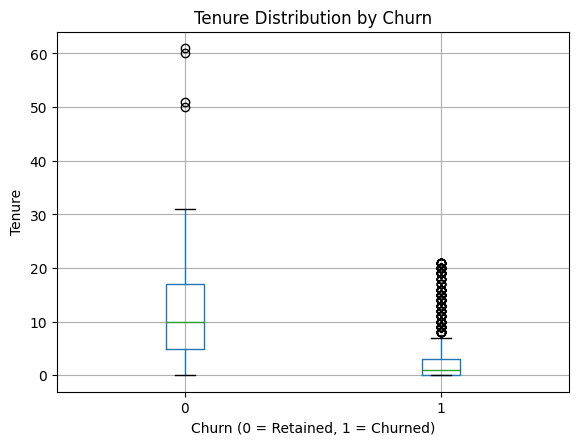

In [3]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="Tenure",
    by="Churn"
)

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Tenure")

plt.show()

### Observation
Churned customers generally have much lower tenure than retained customers, indicating that customers are particularly vulnerable to churn during the early stage of their relationship with the company.

## Preferred Order Category

In [4]:
category_churn = (
    df.groupby("PreferedOrderCat")["Churn"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

category_churn["ChurnRate"] = category_churn["mean"] * 100

category_churn

,count,mean,ChurnRate
PreferedOrderCat,,,
Mobile Phone,1271,0.275374,27.537372
Mobile,809,0.271941,27.194067
Fashion,826,0.154964,15.496368
Laptop & Accessory,2050,0.102439,10.243902
Others,264,0.075758,7.575758
Grocery,410,0.048780,4.878049


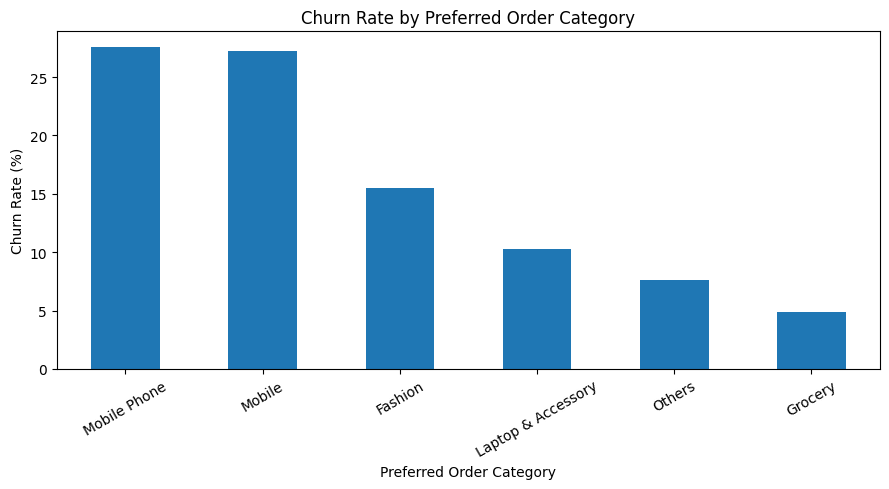

In [5]:
plt.figure(figsize=(9, 5))

category_churn["ChurnRate"].plot(kind="bar")

plt.title("Churn Rate by Preferred Order Category")
plt.xlabel("Preferred Order Category")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observation
Mobile Phone and Mobile customers have the highest observed churn rates, at approximately 27%, while Grocery customers have the lowest churn rate at approximately 5%.
*  **This suggests that customer retention strategies may need to be tailored to different product categories.**

## Payment Mode

In [6]:
payment_churn = (
    df.groupby("PreferredPaymentMode")["Churn"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

payment_churn["ChurnRate"] = payment_churn["mean"] * 100

payment_churn

,count,mean,ChurnRate
PreferredPaymentMode,,,
Cash on Delivery,514,0.249027,24.902724
E wallet,614,0.228013,22.801303
UPI,414,0.173913,17.391304
Debit Card,2314,0.153846,15.384615
Credit Card,1774,0.142052,14.205186


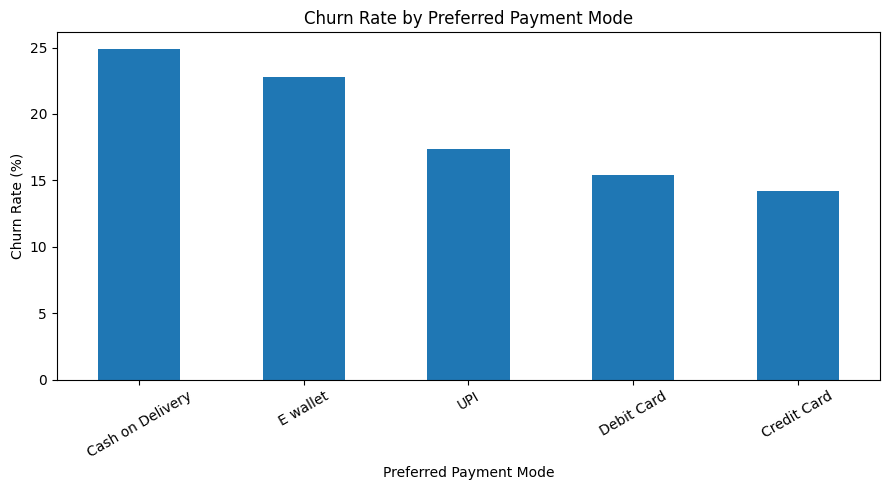

In [7]:
plt.figure(figsize=(9, 5))

payment_churn["ChurnRate"].plot(kind="bar")

plt.title("Churn Rate by Preferred Payment Mode")
plt.xlabel("Preferred Payment Mode")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observation
Payment mode shows meaningful differences

Churn rates vary across payment methods, with Cash on Delivery customers showing the highest churn rate at 24.90%, followed by E-wallet users at 22.80%. Credit Card customers have the lowest churn rate at 14.21%.

* **These differences suggest that payment preferences can help identify customer segments requiring closer retention monitoring.**

## Complaints

In [8]:
complaint_churn = (
    df.groupby("Complain")["Churn"]
    .agg(["count", "mean"])
)

complaint_churn["ChurnRate"] = complaint_churn["mean"] * 100

complaint_churn.index = ["No Complaint", "Complaint"]

complaint_churn

,count,mean,ChurnRate
No Complaint,4026,0.109290,10.928962
Complaint,1604,0.316708,31.670823


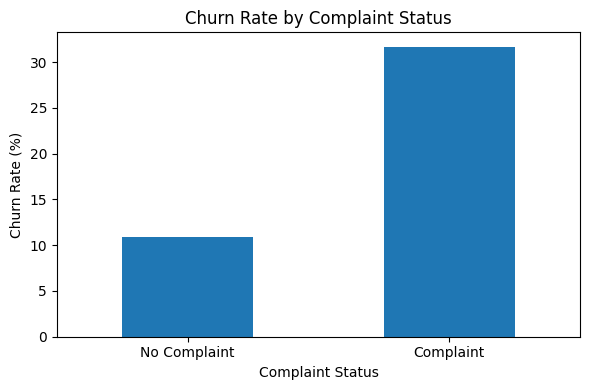

In [9]:
plt.figure(figsize=(6, 4))

complaint_churn["ChurnRate"].plot(kind="bar")

plt.title("Churn Rate by Complaint Status")
plt.xlabel("Complaint Status")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation
Complaints are strongly associated with churn

Customers who complained have almost 3× the churn rate of customers without complaints.

Customers who reported complaints had a substantially higher churn rate of 31.67%, compared with 10.93% among customers without complaints. T**his suggests that complaint resolution and customer service quality should be important components of the retention strategy.**

## Warehouse-to-Home Distance

In [10]:
df["DistanceGroup"] = pd.cut(
    df["WarehouseToHome"],
    bins=[0, 10, 20, 30, float("inf")],
    labels=["≤10", "11–20", "21–30", ">30"]
)

distance_churn = (
    df.groupby("DistanceGroup", observed=False)["Churn"]
    .agg(["count", "mean"])
)

distance_churn["ChurnRate"] = distance_churn["mean"] * 100

distance_churn

,count,mean,ChurnRate
DistanceGroup,,,
≤10,1969,0.135094,13.509396
11–20,2067,0.156749,15.674891
21–30,874,0.201373,20.137300
>30,469,0.208955,20.895522


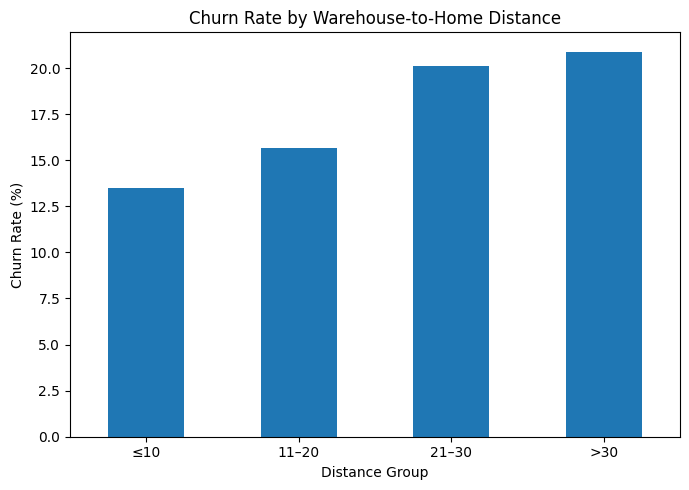

In [11]:
plt.figure(figsize=(7, 5))

distance_churn["ChurnRate"].plot(kind="bar")

plt.title("Churn Rate by Warehouse-to-Home Distance")
plt.xlabel("Distance Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation
Longer delivery distance is associated with higher churn

There's a clear upward pattern:

13.51% ---> 15.67% ---> 20.14% ---> 20.90%

Customers living farther from the warehouse show higher observed churn.

Churn rate increases as warehouse-to-home distance increases, rising from 13.51% for customers within 10 units of distance to 20.90% for customers beyond 30 units. This indicates that **delivery-related factors may be relevant to customer retention**, particularly for customers located farther from fulfillment centers.

## New Customer VS Existing

In [12]:
df["CustomerTenureGroup"] = df["Tenure"].apply(
    lambda x: "New Customer" if x <= 6 else "Existing Customer"
)

tenure_group_churn = (
    df.groupby("CustomerTenureGroup")["Churn"]
    .agg(["count", "mean"])
)

tenure_group_churn["ChurnRate"] = tenure_group_churn["mean"] * 100

tenure_group_churn

,count,mean,ChurnRate
CustomerTenureGroup,,,
Existing Customer,3480,0.072126,7.212644
New Customer,2150,0.324186,32.418605


### Observation
* New customers are the highest-risk segment

New customers have a substantially higher churn rate than existing customers, with churn rates of 32.42% and 7.21% respectively.

This indicates that the early customer lifecycle is a critical period for retention and should be a major focus of customer engagement strategies.

# Business Recommendations

Based on the exploratory analysis, statistical testing and machine learning results, the following retention strategies are recommended.

### 1. Focus on new customer onboarding
New customers show substantially higher churn than existing customers. The company should introduce stronger onboarding, early engagement campaigns and incentives during the first few months of the customer lifecycle.

### 2. Prioritize complaint resolution
Customers who reported complaints showed considerably higher churn. Customer service teams should prioritize complaint resolution and follow up with customers after an issue has been addressed.

### 3. Monitor customers with longer delivery distances
Customers located farther from warehouses show higher churn rates. Delivery times, logistics performance and service quality should be monitored for these customers.

### 4. Target high-risk product categories
Mobile and Mobile Phone customers show substantially higher churn rates than categories such as Grocery. Retention campaigns can therefore be tailored to customers purchasing these categories.

### 5. Monitor high-risk payment segments
Cash on Delivery and E-wallet customers show higher observed churn rates. These segments can be monitored more closely and targeted with appropriate payment incentives or engagement campaigns.

### 6. Use the ML model for proactive retention
The Random Forest model can be used to identify customers with a high probability of churn. Instead of applying retention campaigns to every customer, the company can prioritize high-risk customers and allocate retention resources more efficiently.